In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("./dataset/Titanic-Dataset.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
data = data.drop(columns=["PassengerId", "Name", "Cabin", "Ticket"])
data = data.dropna()

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 712 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  712 non-null    int64  
 1   Pclass    712 non-null    int64  
 2   Sex       712 non-null    object 
 3   Age       712 non-null    float64
 4   SibSp     712 non-null    int64  
 5   Parch     712 non-null    int64  
 6   Fare      712 non-null    float64
 7   Embarked  712 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 50.1+ KB


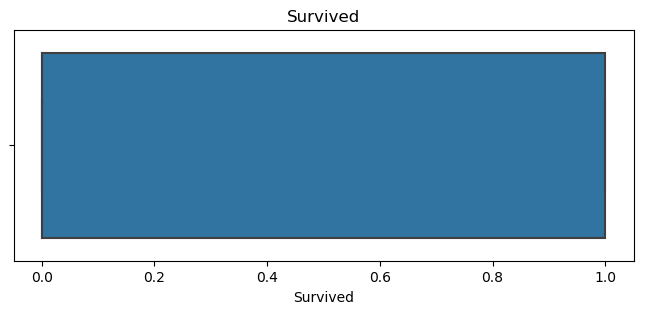

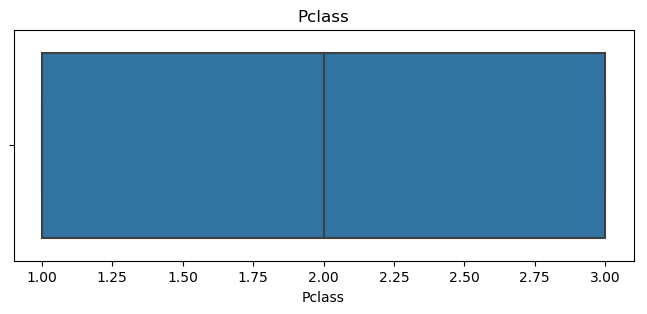

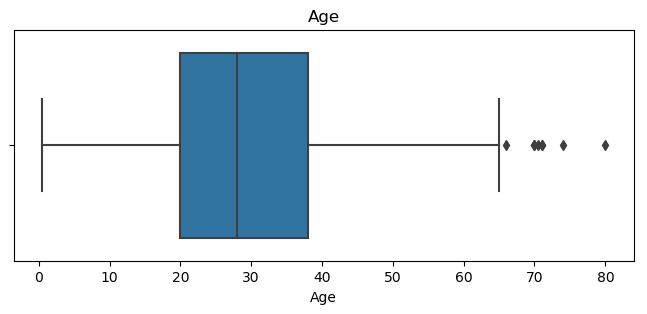

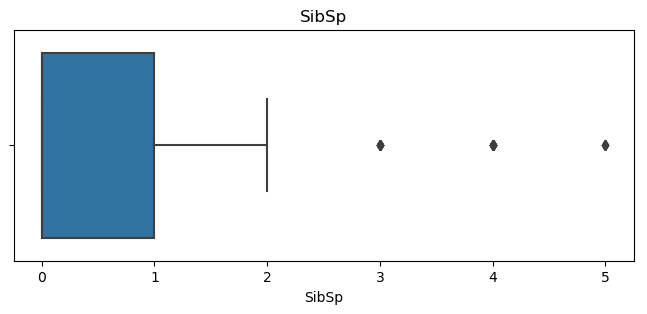

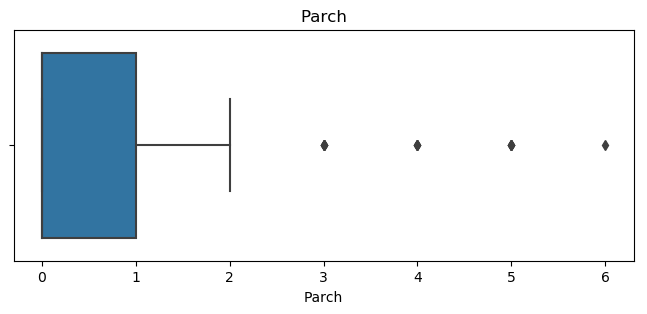

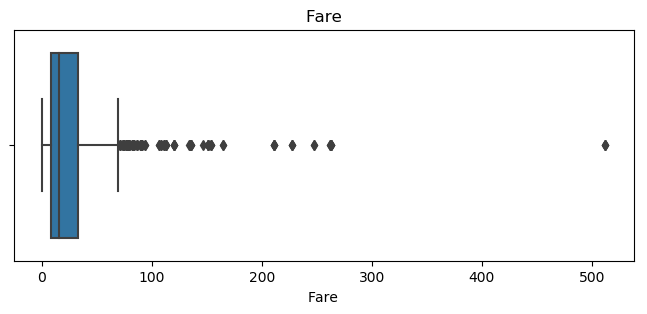

In [6]:
num_cols = data.select_dtypes(include='number')
for col in num_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(data[col])
    plt.title(col)
    plt.show()

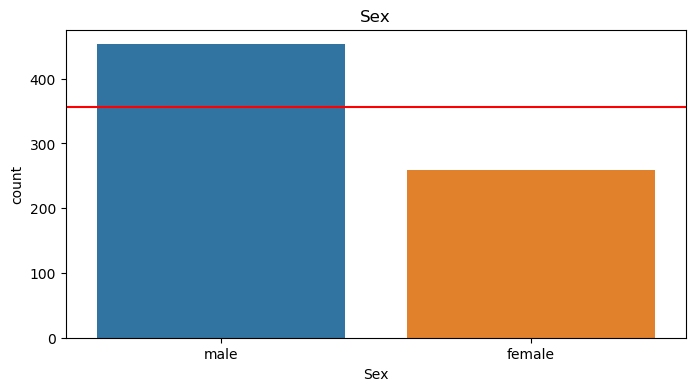

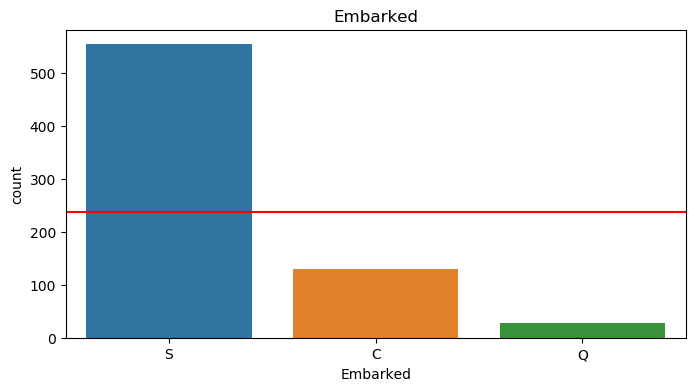

In [7]:
obj_cols = data.select_dtypes(include='object')
for col in obj_cols:
    mean_cnt = len(data[col])/len(np.unique(data[col]))
    plt.figure(figsize=(8,4))
    sns.countplot(data[col])
    plt.axhline(mean_cnt, color="red")
    plt.title(col)
    plt.show()

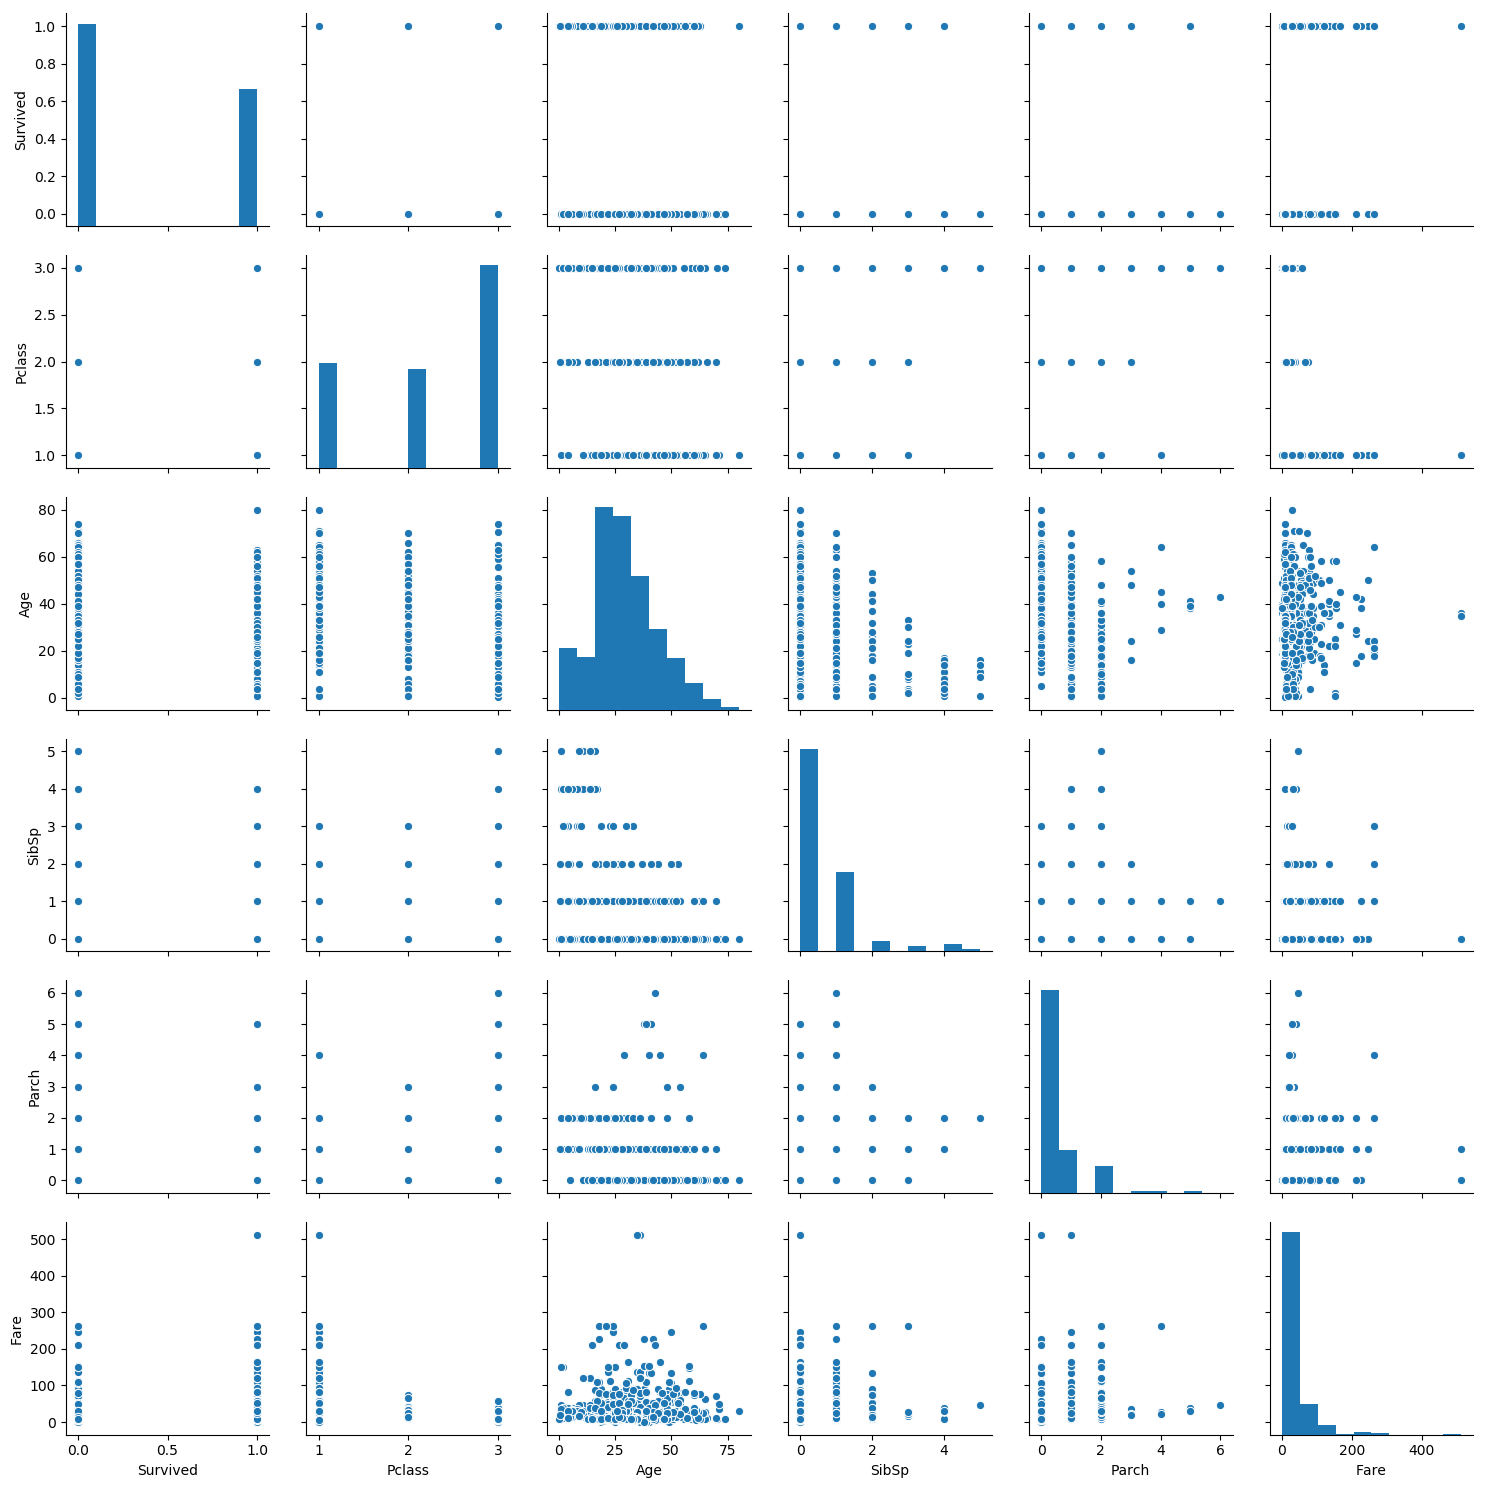

In [8]:
sns.pairplot(num_cols)
plt.show()

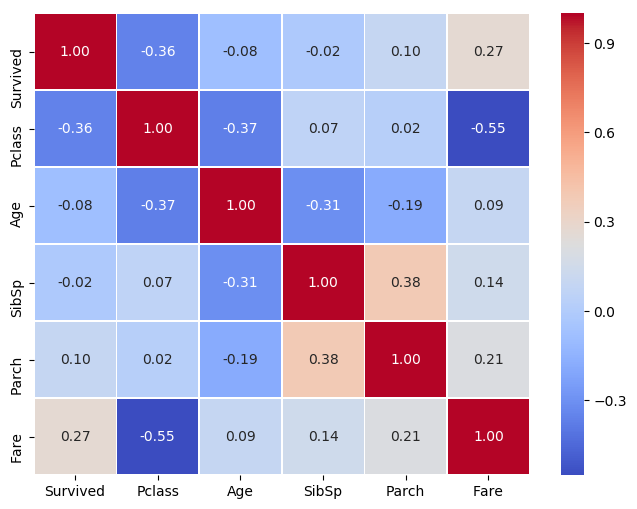

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.show()

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 712 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  712 non-null    int64  
 1   Pclass    712 non-null    int64  
 2   Sex       712 non-null    object 
 3   Age       712 non-null    float64
 4   SibSp     712 non-null    int64  
 5   Parch     712 non-null    int64  
 6   Fare      712 non-null    float64
 7   Embarked  712 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 70.1+ KB


In [15]:
Pclass_dummies = pd.get_dummies(data["Pclass"], prefix="Pclass", drop_first=True)
Sex_dummies = pd.get_dummies(data["Sex"], prefix="Sex", drop_first=True)
Embarked_dummies = pd.get_dummies(data["Embarked"], prefix="Embarked", drop_first=True)

In [16]:
data = pd.concat([data.drop(columns=["Pclass", "Sex", "Embarked"]), Pclass_dummies, Sex_dummies, Embarked_dummies], axis=1)
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 712 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    712 non-null    int64  
 1   Age         712 non-null    float64
 2   SibSp       712 non-null    int64  
 3   Parch       712 non-null    int64  
 4   Fare        712 non-null    float64
 5   Pclass_2    712 non-null    uint8  
 6   Pclass_3    712 non-null    uint8  
 7   Sex_male    712 non-null    uint8  
 8   Embarked_Q  712 non-null    uint8  
 9   Embarked_S  712 non-null    uint8  
dtypes: float64(2), int64(3), uint8(5)
memory usage: 56.9 KB


In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler_mm = MinMaxScaler()

data_mm = scaler_mm.fit_transform(data)

In [25]:
from scipy import stats

shapiro_stat_normal, shapiro_p_normal = stats.shapiro(data_mm[0])
print(f"Statistic: {shapiro_stat_normal} / p-value: {shapiro_p_normal}")

Statistic: 0.7058812379837036 / p-value: 0.001038063783198595


In [ ]:
from scipy.stats import pearsonr,spearmanr

corr, p_value = spearmanr(data["Survived"], data["Survived"])